# 01 Dataset and Task

This notebook is the entry point for the project walkthrough. It documents the recommendation use case, the raw Myket dataset, and the key dataset properties that motivate the modeling choices used later in the repo.

## What this notebook establishes
- The task is **top-K Android app recommendation** from implicit install history.
- Each row in `myket-android-application-market-dataset/myket.csv` is treated as an observed user-app install interaction.
- Non-observed apps are unknown candidates, not explicit negative feedback.
- App metadata is available in `myket-android-application-market-dataset/app_info_sample.csv`, but aggregate fields such as installs and ratings must be handled carefully because the dataset documentation warns they were collected during the interaction period.

## Implementation references
- Dataset source files: `myket-android-application-market-dataset/myket.csv`, `myket-android-application-market-dataset/app_info_sample.csv`
- Dataset description: `myket-android-application-market-dataset/README.md`
- Loading helpers used by this walkthrough: `analysis/shared_utils.py`

The outputs below summarize the dataset size, interaction distribution, metadata columns, and long-tail popularity behavior that shape the rest of the project.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display, Markdown

from analysis.shared_utils import DATASET_DIR, load_item_metadata, load_raw_dataset

raw_df = load_raw_dataset()
meta_df = load_item_metadata()

summary = pd.DataFrame(
    [
        {
            "raw_rows": len(raw_df),
            "unique_users": raw_df["user_id"].nunique(),
            "unique_items": raw_df["item_id"].nunique(),
            "timestamp_min": int(raw_df["timestamp"].min()),
            "timestamp_max": int(raw_df["timestamp"].max()),
            "metadata_rows": len(meta_df),
            "metadata_columns": ", ".join(meta_df.columns.astype(str)),
        }
    ]
)

display(Markdown("## Dataset Snapshot"))
display(summary)

display(Markdown("## Raw Interaction Sample"))
display(raw_df.head())

display(Markdown("## Metadata Sample"))
display(meta_df.head())

safe_metadata = ["category", "category_en"]
risky_metadata = [col for col in ["installs", "avg_rating", "rating_count"] if col in meta_df.columns]
print("Safe metadata candidates:", safe_metadata)
print("Risky metadata columns to avoid for future prediction:", risky_metadata)
print("README path:", DATASET_DIR / "README.md")

## Dataset Snapshot

,raw_rows,unique_users,unique_items,timestamp_min,timestamp_max,metadata_rows,metadata_columns
0,694121,10000,7988,0,17021023,7606,"app_name, installs, rating, rating_count, cate..."


## Raw Interaction Sample

,user_id,item_id,timestamp,state_label,feature_1,feature_2
0,-1185417981,com.tencent.ig,0.000,0,0,0
1,-562407438,com.tencent.iglite,220.347,0,0,0
2,508973892,com.pst.pes18,236.327,0,0,0
3,2117726268,com.caesars.irzclash,248.113,0,0,0
4,1703610105,com.xmgame.savethegirl,317.667,0,0,0


## Metadata Sample

,app_name,installs,rating,rating_count,category_fa,category_en
0,abdorahman.khorram.top,30000.0,2.25,4,آموزشی,Educational
1,abi.asteghlal.good,10000.0,4.71,65,سرگرمی,Entertainment
2,abt.book.s7,32000.0,2.98,306,آموزشی,Educational
3,abt.book.s8,26000.0,3.28,266,آموزشی,Educational
4,afb.simple.paint.free,17000.0,4.48,67,سرگرمی,Entertainment


Safe metadata candidates: ['category', 'category_en']
Risky metadata columns to avoid for future prediction: ['installs', 'rating_count']
README path: /Users/ritwikreddy/Desktop/2nd semster/Recommender Systems/final_project/recommender_systems/myket-android-application-market-dataset/README.md


In [2]:
top_items = raw_df["item_id"].value_counts().head(10).rename_axis("item_id").reset_index(name="interaction_count")
user_activity = raw_df.groupby("user_id").size().describe().to_frame("user_interaction_stats")
item_activity = raw_df.groupby("item_id").size().describe().to_frame("item_interaction_stats")

print("Top 10 most frequent apps in the raw interaction file")
display(top_items)

print("User activity distribution")
display(user_activity)

print("Item activity distribution")
display(item_activity)

print(
    "Working task statement:\n"
    "Given each user's past app installs, rank unseen apps so the top-K list overlaps future installs."
)

Top 10 most frequent apps in the raw interaction file


,item_id,interaction_count
0,com.instagram.android,15292
1,ir.resaneh1.iptv,12143
2,com.tencent.ig,7919
3,com.ForgeGames.SpecialForcesGroup2,7797
4,ir.nomogame.ClutchGame,6193
5,com.dts.freefireth,6041
6,com.whatsapp,5876
7,com.supercell.clashofclans,5817
8,com.mojang.minecraftpe,5649
9,com.lenovo.anyshare.gps,5076


User activity distribution


,user_interaction_stats
count,10000.00000
mean,69.41210
std,46.41251
min,33.00000
25%,41.00000
50%,54.00000
75%,80.00000
max,1053.00000


Item activity distribution


,item_interaction_stats
count,7988.000000
mean,86.895468
std,355.739904
min,1.000000
25%,17.000000
50%,28.000000
75%,61.000000
max,15292.000000


Working task statement:
Given each user's past app installs, rank unseen apps so the top-K list overlaps future installs.


## Popularity Bias and Long-Tail Visualization

The plots below summarize item popularity in the raw interaction file. The histogram shows how many apps fall into different interaction-count ranges, while the rank-frequency curve shows how sharply interaction volume drops from the most popular apps into the long tail.

This matters for the modeling sections because popularity bias is strong in this dataset: a few head apps receive a large share of interactions, while many apps have limited signal. The later baselines and variants are interpreted against this long-tail behavior.

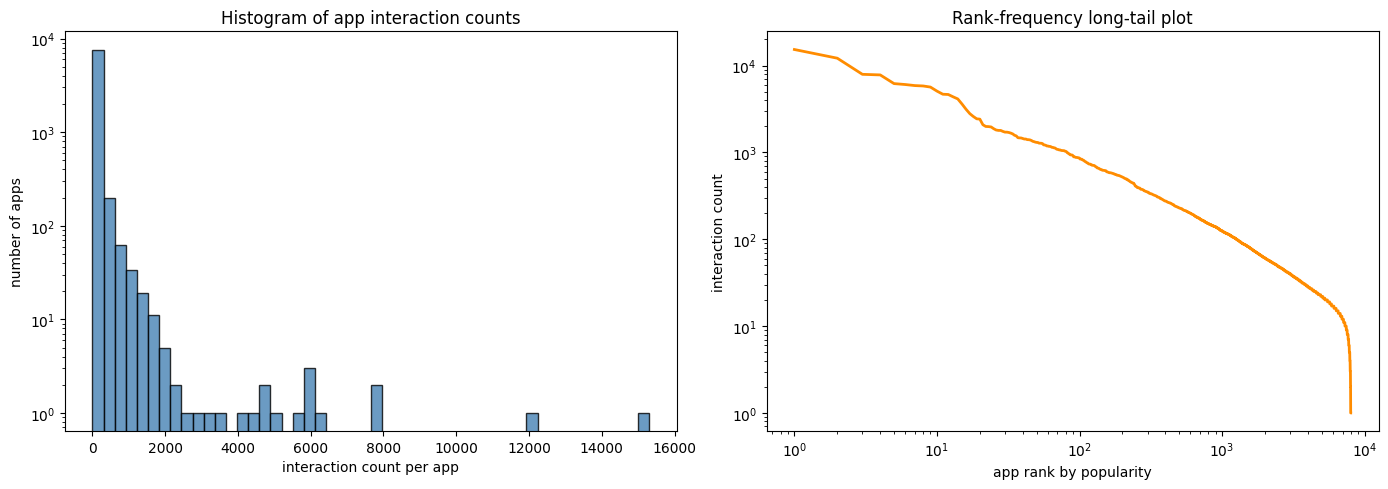

Interaction concentration among the most popular apps
- top_1_pct_items_share: 28.08%
- top_5_pct_items_share: 50.39%
- top_10_pct_items_share: 62.04%
Interpretation:
If the right-hand curve drops sharply and then stretches into a long flat tail, the dataset has a classic long-tail popularity pattern.
That means a small number of apps dominate interactions, while many apps are comparatively rare.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

item_counts = raw_df.groupby("item_id").size().sort_values(ascending=False)
rank = np.arange(1, len(item_counts) + 1)

# How concentrated are interactions in the most popular apps?
total_interactions = item_counts.sum()
top_1_pct = max(1, int(np.ceil(0.01 * len(item_counts))))
top_5_pct = max(1, int(np.ceil(0.05 * len(item_counts))))
top_10_pct = max(1, int(np.ceil(0.10 * len(item_counts))))

concentration = {
    "top_1_pct_items_share": item_counts.iloc[:top_1_pct].sum() / total_interactions,
    "top_5_pct_items_share": item_counts.iloc[:top_5_pct].sum() / total_interactions,
    "top_10_pct_items_share": item_counts.iloc[:top_10_pct].sum() / total_interactions,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of item popularity
axes[0].hist(item_counts, bins=50, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Histogram of app interaction counts")
axes[0].set_xlabel("interaction count per app")
axes[0].set_ylabel("number of apps")
axes[0].set_yscale("log")

# Rank-frequency long-tail plot
axes[1].plot(rank, item_counts.to_numpy(), color="darkorange", linewidth=2)
axes[1].set_title("Rank-frequency long-tail plot")
axes[1].set_xlabel("app rank by popularity")
axes[1].set_ylabel("interaction count")
axes[1].set_xscale("log")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print("Interaction concentration among the most popular apps")
for label, value in concentration.items():
    print(f"- {label}: {value:.2%}")

print(
    "Interpretation:\n"
    "If the right-hand curve drops sharply and then stretches into a long flat tail, the dataset has a classic long-tail popularity pattern.\n"
    "That means a small number of apps dominate interactions, while many apps are comparatively rare."
)